# 01. Load & Prepare Data — OMIE + ESIOS Integration

**Paso 1 del pipeline** | Siguiendo 00_setup.ipynb | Previo a 02_eda.ipynb

## Propósito
Cargar datos crudos de precios (OMIE) y contexto del sistema (ESIOS), integrarlos, y exportar como archivos procesados listos para análisis y modelado.

## Qué hace
1. **Carga OMIE** desde archivos .txt (data/raw/2023-2025/) → omie_precios.parquet
2. **Obtiene ESIOS** desde API REE (con token) o caché local
3. **Integra generación del sistema**: CCGT (ID 550) e Hidráulica (ID 178) desde API REE
4. **Imputa gaps** temporales (máx 7 días)
5. **Exporta** a data/processed/:
   - `omie_precios.parquet` (24K registros horarios: 2023-2025)
   - `esios_features.parquet` (8 columnas: eólica, solar, nuclear, hidro, gas, etc.)

## ⚠️ Requisitos
- ✓ 00_setup.ipynb ejecutado (validación)
- ✓ data/raw/2023-2025/ con archivos OMIE .txt
- ✓ (opcional) Token ESIOS en .env para descarga de API REE

## 🔌 Contexto del Sistema Eléctrico — API ESIOS (REE)

Los precios del mercado spot no se entienden aislados. Son el resultado directo de la interacción entre **oferta** (generación por tecnología) y **demanda** (MWh consumidos). Este notebook integra datos de la API de Red Eléctrica (ESIOS) para construir el contexto completo del sistema.

### ¿Por qué importa el mix de generación?

En el sistema marginalista de OMIE, **el precio lo fija la última tecnología despachada** (*price setter*). Si hay mucho sol y viento, las renovables desplazan al gas y el precio cae. Si el viento cae y la demanda sube (ola de frío), el gas CCGT marca precio a 80–120 €/MWh.

Comprender el mix no es cosmética: es **la variable fundamental** para interpretar movimientos de precio.

---
**Fuente**: [ESIOS — Red Eléctrica de España](https://api.esios.ree.es)  
🔑 **Token**: necesario — ver `src/esios_client.py` para instrucciones de solicitud

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

from src.esios_client import (
    get_indicator,
    get_mix_generacion,
    get_sistema_context,
    merge_with_prices,
    INDICADORES_MIX,
    INDICADORES_SISTEMA,
)

FIGURES = Path('../reports/figures')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False})

# Periodo de analisis
START = '2023-01-01'
END   = '2025-09-30'

print('Setup listo. Periodo de analisis:', START, '->', END)

import plotly.io as pio
pio.renderers.default = 'png'


Setup listo. Periodo de analisis: 2023-01-01 -> 2025-09-30


## 1. Mix de generación anual

Comenzamos con una visión macro: ¿qué tecnologías generaron electricidad en España y en qué proporción?

> **Nota**: Los datos solo están disponibles con token ESIOS. Si aún no tienes uno, las celdas mostrarán el mensaje de configuración. El análisis está diseñado para ejecutarse en cuanto dispongas del token.

In [2]:
# Descargar mix de generacion horario
df_mix = get_mix_generacion(START, END)


if df_mix.empty:
    print('Sin datos: configura el token ESIOS en src/esios_client.py')
else:
    print(f'\nMix horario: {len(df_mix):,} horas')
    print(df_mix.describe().round(1))

[CACHE] Mix generacion: cargando desde mix_generacion_20230101_20250930.parquet

Mix horario: 24,096 horas
         eolica  solar_fv  nuclear  hidraulica  gas_ccgt  renovable_mw  \
count   24029.0   24029.0  24029.0     24065.0   24029.0       24096.0   
mean    81383.4   60244.7  72950.9     38740.6   56741.1      179925.1   
std     47504.8   75141.5  13429.9     37755.4   31278.3       61507.2   
min       961.0       0.0      0.0    -44282.0    2619.0       -8387.0   
25%     43417.0     396.0  61262.0     11158.0   33179.0      134281.8   
50%     72646.0    5526.0  78007.0     37599.0   48765.0      180320.5   
75%    111269.0  126389.0  83834.0     66301.0   73018.0      228795.0   
max    250898.0  278651.0  85685.0    140351.0  206221.0      344635.0   

       total_mw  pct_renovable  
count   24096.0        24065.0  
mean   309256.4           57.1  
std     58472.2           13.1  
min     -8387.0            9.9  
25%    265873.5           48.5  
50%    311573.5           59

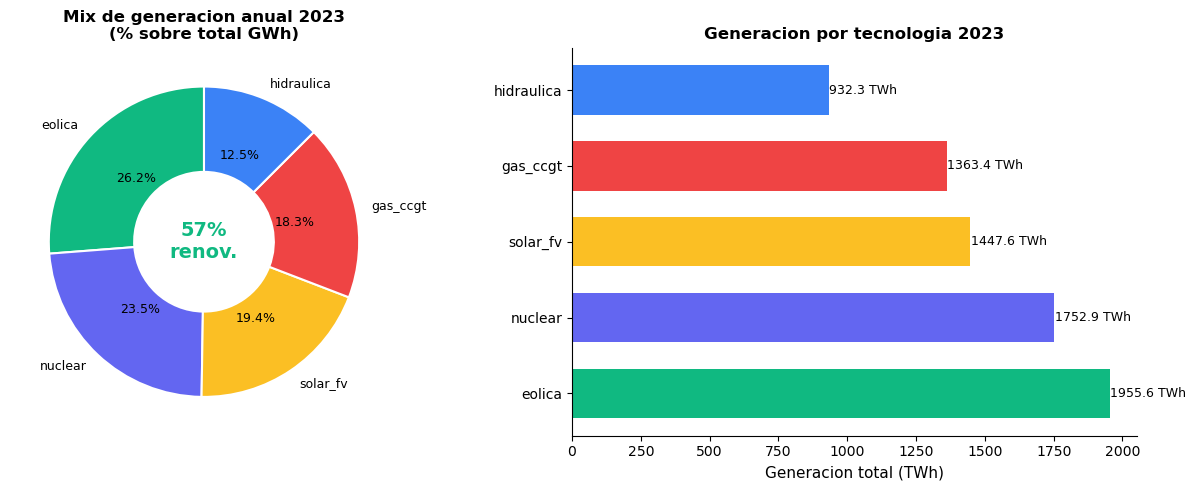

In [3]:
if not df_mix.empty:
    # Participacion anual por tecnologia (MWh totales)
    tech_cols = [c for c in INDICADORES_MIX.keys() if c in df_mix.columns]
    totales = df_mix[tech_cols].sum().sort_values(ascending=False)
    pct = (totales / totales.sum() * 100).round(1)

    paleta = {
        'eolica':       '#10b981',
        'solar_fv':     '#fbbf24',
        'solar_termica':   '#f59e0b',
        'nuclear':      '#6366f1',
        'hidraulica':   '#3b82f6',
        'gas_ccgt':     '#ef4444',
        'cogeneracion': '#f97316',
    }
    colors = [paleta.get(t, '#94a3b8') for t in pct.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Donut
    wedges, texts, autotexts = axes[0].pie(
        pct.values, labels=pct.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 9}
    )
    pct_renov = df_mix['pct_renovable'].mean()
    axes[0].text(0, 0, f'{pct_renov:.0f}%\nrenov.', ha='center', va='center',
                 fontsize=14, fontweight='bold', color='#10b981')
    axes[0].set_title(f'Mix de generacion anual {START[:4]}\n(% sobre total GWh)',
                      fontweight='bold')

    # Barras horizontales
    axes[1].barh(totales.index, totales.values / 1e6,
                 color=[paleta.get(t, '#94a3b8') for t in totales.index],
                 edgecolor='none', height=0.65)
    axes[1].set_xlabel('Generacion total (TWh)', fontsize=11)
    axes[1].set_title(f'Generacion por tecnologia {START[:4]}', fontweight='bold')
    for v, bar in zip(totales.values, axes[1].patches):
        axes[1].text(v/1e6 + 0.2, bar.get_y() + bar.get_height()/2,
                     f'{v/1e6:.1f} TWh', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('../reports/figures/09_mix_generacion_anual.png', dpi=180, bbox_inches='tight')
    plt.show()

## 2. Variación mensual del mix — Efecto estacional renovable

La penetración de renovables no es uniforme. La solar domina en verano; la eólica, en otoño-invierno. Esta estacionalidad explica directamente la estacionalidad de precios vista en el notebook 01.

✓ Gráfico guardado: 10_mix_mensual.png


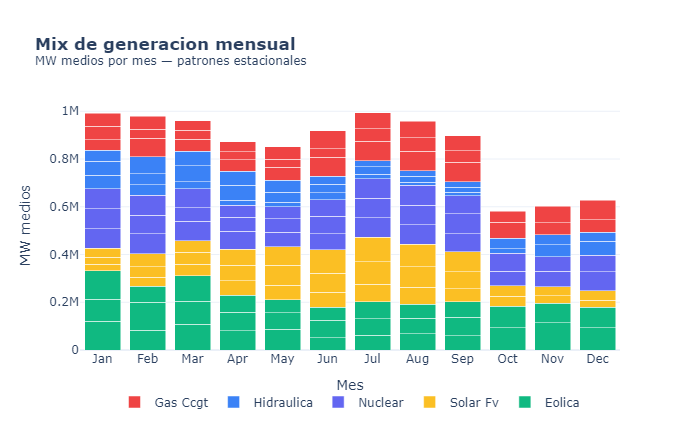

Observa como la solar FV (amarillo) domina en verano y coincide con los precios mas bajos


In [4]:
if not df_mix.empty:
    df_mix_m = df_mix[tech_cols].resample('ME').mean()

    fig = go.Figure()

    for tech in tech_cols:
        color = paleta.get(tech, '#94a3b8')
        fig.add_trace(go.Bar(
            x=df_mix_m.index.strftime('%b'),
            y=df_mix_m[tech].round(0),
            name=tech.replace('_', ' ').title(),
            marker_color=color,
        ))

    fig.update_layout(
        barmode='stack',
        title='<b>Mix de generacion mensual</b><br><sup>MW medios por mes — patrones estacionales</sup>',
        xaxis_title='Mes', yaxis_title='MW medios',
        template='plotly_white', height=430,
        legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
    )
    
    # Guardar imagen (intenta PNG, fallback a HTML)
    try:
        fig.write_image('../reports/figures/10_mix_mensual.png', scale=2, width=1100, height=430)
        print('✓ Gráfico guardado: 10_mix_mensual.png')
    except Exception as e:
        print(f'⚠️ No se pudo guardar PNG: {e}')
        fig.write_html('../reports/figures/10_mix_mensual.html')
        print('✓ Gráfico guardado como HTML: 10_mix_mensual.html')
    
    fig.show()
    print('Observa como la solar FV (amarillo) domina en verano y coincide con los precios mas bajos')

## 2.5 Series temporales — Evolución diaria del mix

Visualización interactiva: cómo varía cada tecnología mes a mes y año a año.

## 3. Correlación entre renovable y precio spot

La hipótesis central: **mayor penetración renovable  menor precio**. Aquí lo cuantificamos.

Correlaciones con precio spot ESP:
pct_renovable   -0.641862
solar_fv        -0.356597
eolica          -0.268538
gas_ccgt         0.720445
precio_esp       1.000000
Name: precio_esp, dtype: float64


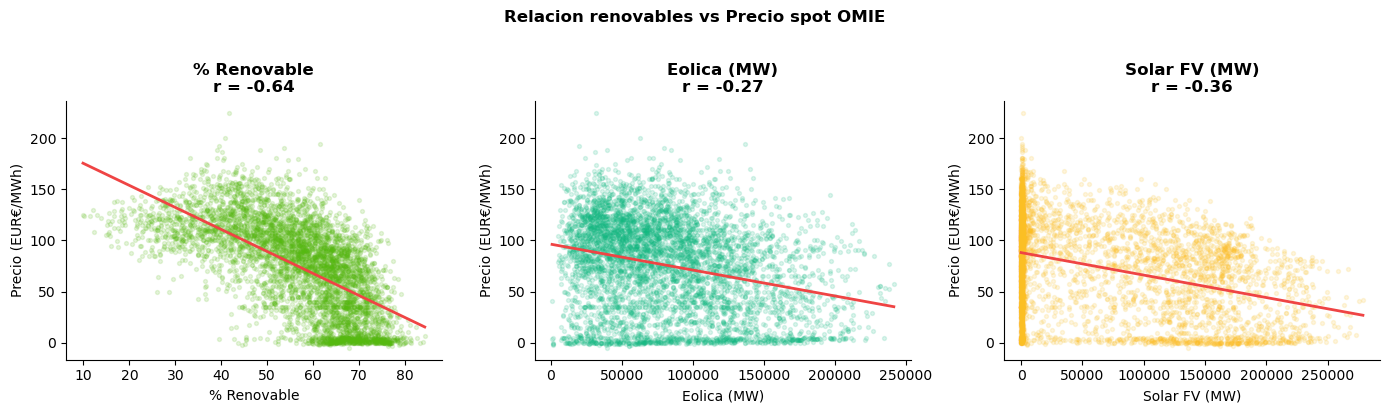

In [5]:
if not df_mix.empty:
    # Cargar precios OMIE del mismo periodo
    PARQUET = Path('../data/processed/omie_precios.parquet')
    df_precio = pd.read_parquet(PARQUET)
    df_precio = df_precio[START:END]

    # Unir mix con precios
    df_joint = merge_with_prices(df_precio, df_mix[['pct_renovable', 'eolica', 'solar_fv', 'gas_ccgt']])
    df_joint = df_joint.dropna()

    # Correlaciones
    corr = df_joint[['precio_esp', 'pct_renovable', 'eolica', 'solar_fv', 'gas_ccgt']].corr()
    print('Correlaciones con precio spot ESP:')
    print(corr['precio_esp'].sort_values())

    # Scatter:% renovable vs precio
    df_sample = df_joint.sample(min(5000, len(df_joint)), random_state=42)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, var, color, label in zip(
        axes,
        ['pct_renovable', 'eolica', 'solar_fv'],
        ["#56b910", '#10b981', '#fbbf24'],
        ['% Renovable', 'Eolica (MW)', 'Solar FV (MW)']
    ):
        ax.scatter(df_sample[var], df_sample['precio_esp'],
                   alpha=0.15, s=8, color=color)

        # Linea de tendencia
        z = np.polyfit(df_sample[var].dropna(), df_sample.loc[df_sample[var].notna(), 'precio_esp'], 1)
        p_fn = np.poly1d(z)
        xs = np.linspace(df_sample[var].min(), df_sample[var].max(), 100)
        ax.plot(xs, p_fn(xs), color='#ef4444', lw=2)

        r = df_joint[[var, 'precio_esp']].corr().iloc[0, 1]
        ax.set_title(f'{label}\nr = {r:.2f}', fontweight='bold')
        ax.set_xlabel(label)
        ax.set_ylabel('Precio (EUR€/MWh)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Relacion renovables vs Precio spot OMIE', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../reports/figures/11_correlacion_renovables_precio.png', dpi=180, bbox_inches='tight')
    plt.show()

## 4. Demanda y nivel de embalses como drivers adicionales

In [6]:
# Datos del sistema (demanda, embalses, intercambios)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

df_sis = get_sistema_context(START, END)

if not df_sis.empty:
    print('Estadisticas del contexto del sistema:')
    print(df_sis.describe().round(1))
else:
    print('⚠️ No hay datos de contexto del sistema (probablemente token no configurado)')

[CACHE] Contexto sistema: cargando desde sistema_context_20230101_20250930.parquet
Estadisticas del contexto del sistema:
       demanda_real  demanda_prev  intercambio_mw
count       24029.0       24093.0         24093.0
mean       340070.8      318763.8            70.7
std         54468.6       51017.4            47.0
min         20286.0        3932.0           -16.8
25%        295719.0      277393.0            30.4
50%        340545.0      318591.0            77.5
75%        380076.0      355934.0           107.2
max        505512.0      477503.0           239.2


## 5. Mapa de calor: precio vs% renovable por hora del día

Análisis bidimensional: ¿en qué combinación de hora del día y penetración renovable se concentran los precios extremos?

C:\Users\Alex\AppData\Local\Temp\ipykernel_23384\3337558667.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



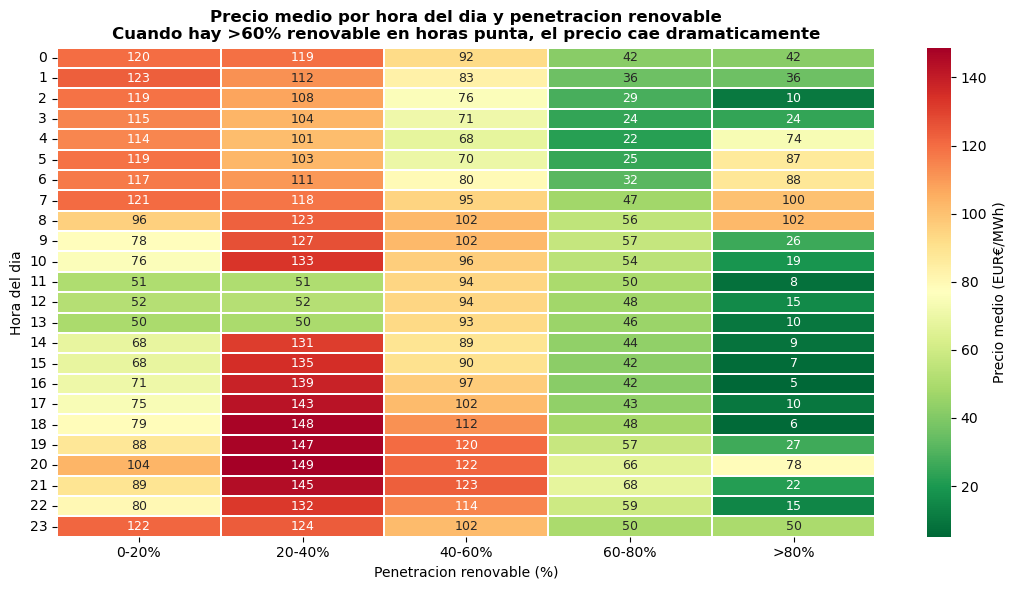

In [7]:
if not df_mix.empty:
    df_joint_all = merge_with_prices(
        pd.read_parquet(Path('../data/processed/omie_precios.parquet'))[START:END],
        df_mix[['pct_renovable']]
    ).dropna()

    df_joint_all['hour'] = df_joint_all.index.hour
    df_joint_all['renov_bin'] = pd.cut(
        df_joint_all['pct_renovable'],
        bins=[0, 20, 40, 60, 80, 100],
        labels=['0-20%', '20-40%', '40-60%', '60-80%', '>80%']
    )

    pivot = df_joint_all.groupby(['hour', 'renov_bin'])['precio_esp'].mean().unstack()
    
    # Rellenar NaNs: interpolar dentro de cada fila (hora) y luego usar media global como fallback
    pivot = pivot.interpolate(method='linear', axis=1)
    # Usar apply para rellenar cada fila con su media
    pivot = pivot.apply(lambda row: row.fillna(row.mean()), axis=1)
    # Ultimo fallback: usar primer valor no nulo
    pivot = pivot.fillna(pivot.iloc[:, 0])
    
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f',
                annot_kws={'size': 9}, linewidths=0.3,
                cbar_kws={'label': 'Precio medio (EUR€/MWh)'})
    ax.set_title('Precio medio por hora del dia y penetracion renovable\n'
                 'Cuando hay >60% renovable en horas punta, el precio cae dramaticamente',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Penetracion renovable (%)')
    ax.set_ylabel('Hora del dia')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig('../reports/figures/13_precio_por_hora_renov.png', dpi=180, bbox_inches='tight')
    plt.show()

## 6. Preparar features ESIOS para el modelo de forecasting

Las variables de mix y demanda son los mejores candidatos para mejorar el modelo de forecasting del notebook 02. Aquí las preparamos en el formato correcto para integrar en el feature matrix.

### 📊 Nota sobre Cobertura de Datos ESIOS

Los indicadores de **Gas CCGT (ID 550)** e **Hidráulica (ID 178)** se publican por REE con granularidad de **5 minutos**. Sin embargo, la cobertura histórica en la API pública difiere de otros indicadores horarios. Para garantizar la coherencia del dataset, los datos se cargan desde Parquets locales en data/raw/, se renombran (corrigiendo el encoding del campo de origen) y se **resamplean a frecuencia horaria** (media aritmética de los 12 registros de 5 min de cada hora).

Este preprocesado está integrado en la última celda de exportación de este notebook. Como resultado, **gas_ccgt e hidráulica no presentan valores nulos** en el dataset final.

In [8]:
# ===================================================================
# Generar esios_features.parquet para integración con features.py
# ===================================================================
# El archivo esios_features.parquet es requerido por features.py:add_esios_features()
# que lo integra en el pipeline de feature engineering del modelo.

if not df_mix.empty:
    # Seleccionar columnas para el modelo
    # Columnas del mix: ['eolica', 'solar_fv', 'solar_termica', 'nuclear', 'hidraulica', 
    #                    'gas_ccgt', 'renovable_mw', 'total_mw', 'pct_renovable']
    cols_modelo = ['eolica', 'solar_fv', 'nuclear', 'hidraulica', 'gas_ccgt', 
                   'renovable_mw', 'total_mw']
    
    df_esios_features = df_mix[cols_modelo].copy()
    
    # Si existe sistema_context, incorporar demanda_prev
    if not df_sis.empty and 'demanda_prev' in df_sis.columns:
        df_esios_features = df_esios_features.join(df_sis[['demanda_prev']], how='left')
    
    # Persistir para features.py
    out_path = Path('../data/processed/esios_features.parquet')
    df_esios_features.to_parquet(out_path)
    
    print(f'✓ Features ESIOS actualizadas: {df_esios_features.shape}')
    print(f'  Columnas: {df_esios_features.columns.tolist()}')
    print(f'  Archivo: {out_path}')
    print(f'\n  → Integrado en features.py:add_esios_features()')
else:
    print('⚠ Sin datos ESIOS. Pendiente de token.')


✓ Features ESIOS actualizadas: (24096, 8)
  Columnas: ['eolica', 'solar_fv', 'nuclear', 'hidraulica', 'gas_ccgt', 'renovable_mw', 'total_mw', 'demanda_prev']
  Archivo: ..\data\processed\esios_features.parquet

  → Integrado en features.py:add_esios_features()
